# Opgave 7

In [9]:
import pandas as pd

df = pd.read_csv("results_opg7.csv")
df

,index,raw_value,sorted_value,exact,mse,count_sketch_ms,exact_f2_ms,counter_bitwidth
0,1,11180124,11171892,11184812,36156316.16,10054.4527,14853.4029,23
1,2,11201308,11172108,11184812,36156316.16,10361.1919,14853.4029,23
2,3,11187564,11172132,11184812,36156316.16,10380.2830,14853.4029,23
3,4,11184260,11176212,11184812,36156316.16,10744.3341,14853.4029,23
4,5,11182916,11176332,11184812,36156316.16,10462.4177,14853.4029,23
...,...,...,...,...,...,...,...,...
95,96,11177948,11196780,11184812,36156316.16,10058.9288,14853.4029,23
96,97,11182596,11196884,11184812,36156316.16,9934.4890,14853.4029,23
97,98,11189636,11197452,11184812,36156316.16,9960.3760,14853.4029,23
98,99,11197452,11198268,11184812,36156316.16,9967.4911,14853.4029,23


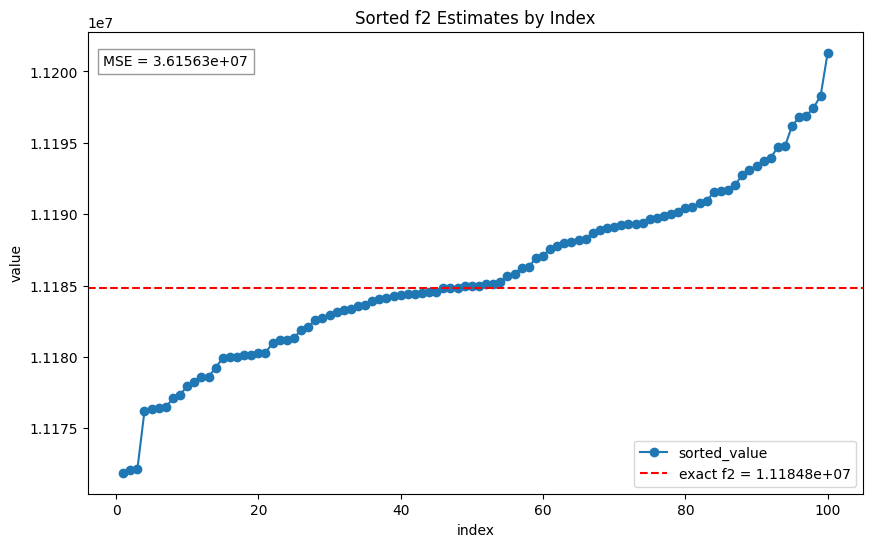

In [10]:
import matplotlib.pyplot as plt

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df['sorted_value'], marker='o', linestyle='-', label='sorted_value')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Sorted f2 Estimates by Index')
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
sorted_f2_ylim = plt.gca().get_ylim()
plt.show()

Vi beregner gennemsnittet for vores estimater og sammenligner med den eksakte F2-værdi,

In [11]:
mean_estimate = df["raw_value"].mean().item()

print(f"Mean of raw_value: {mean_estimate:.6g}")
print(f"Exact f2 value: {exact_f2_value:.6g}")

percentage_error = abs(mean_estimate - exact_f2_value) / exact_f2_value * 100
print(f"Error (|mean - exact|): {abs(mean_estimate - exact_f2_value):.6g} ({percentage_error:.6f}%)")

Mean of raw_value: 1.11857e+07
Exact f2 value: 1.11848e+07
Error (|mean - exact|): 911.84 (0.008152%)


In [12]:
l = df['counter_bitwidth'].iloc[0]
num_buckets = 2 ** l
exp_variance = 2*exact_f2_value**2 / num_buckets
print(f"Expected variance of the estimator: {exp_variance:.6g}")
print(f"Empirical variance of the estimator: {mse_value:.6g}")
print(f"Error (|empirical variance - expected variance|): {abs(mse_value - exp_variance):.6g} ({abs(mse_value - exp_variance) / exp_variance * 100:.6f}%)")

Expected variance of the estimator: 2.98262e+07
Empirical variance of the estimator: 3.61563e+07
Error (|empirical variance - expected variance|): 6.33015e+06 (21.223468%)


## Gruppering

In [13]:
# Split raw_value into groups of 11 elements
group_size = 11
num_groups = 9
raw_values = df['raw_value'].values
groups = {f'G_{i+1}': raw_values[i*group_size:(i+1)*group_size] for i in range(num_groups)}
groups

{'G_1': array([11180124, 11201308, 11187564, 11184260, 11182916, 11184116,
        11184556, 11172108, 11180268, 11189340, 11183260]),
 'G_2': array([11189892, 11185140, 11176212, 11178580, 11190140, 11180012,
        11184844, 11193700, 11182732, 11189276, 11184572]),
 'G_3': array([11191604, 11192068, 11188076, 11176468, 11186292, 11181204,
        11194716, 11191580, 11184060, 11185228, 11184852]),
 'G_4': array([11180116, 11184396, 11179244, 11193372, 11189012, 11172132,
        11198268, 11181220, 11184796, 11184356, 11178244]),
 'G_5': array([11183356, 11189284, 11181308, 11179932, 11188868, 11171892,
        11186244, 11189372, 11184940, 11194764, 11191724]),
 'G_6': array([11188180, 11185644, 11196196, 11180028, 11184412, 11190900,
        11176452, 11192732, 11177356, 11184988, 11190404]),
 'G_7': array([11181916, 11190020, 11196884, 11183548, 11189764, 11190468,
        11187964, 11183940, 11186940, 11190756, 11184468]),
 'G_8': array([11196780, 11184988, 11180956, 11188244, 

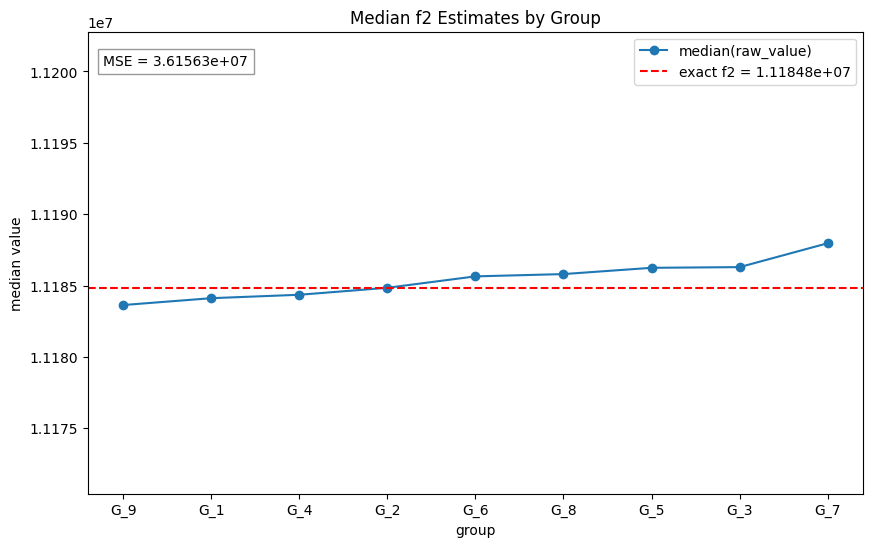

In [14]:
group_size = globals().get('group_size', 11)
raw_values = df['raw_value'].values
num_groups = len(raw_values) // group_size
kvps = {f"G_{i+1}": pd.Series(raw_values[i*group_size:(i+1)*group_size]).median() for i in range(num_groups)}
kvps = {k:v for k,v in sorted(kvps.items(), key=lambda item: item[1])}
group_labels = list(kvps.keys())
medians = list(kvps.values())

exact_f2_value = df['exact'].iloc[0]
mse_value = df['mse'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(group_labels, medians, marker='o', linestyle='-', label='median(raw_value)')
plt.axhline(y=exact_f2_value, color='r', linestyle='--', label=f'exact f2 = {exact_f2_value:.6g}')
plt.title('Median f2 Estimates by Group')
plt.ylim(globals().get('sorted_f2_ylim', plt.gca().get_ylim()))
plt.gca().text(0.02, 0.95, f'MSE = {mse_value:.6g}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.xlabel('group')
plt.ylabel('median value')
plt.legend()
plt.show()


Vi kan se at variansen af disse medianværdier,

In [15]:
import numpy as np
np.array(medians).var(ddof=0)

np.float64(1606030.2222222222)

er markant lavere end variansen for alle estimater,

In [16]:
mse_value

np.float64(36156316.16)

# Opgave 8

In [17]:
df = pd.read_csv("results_opg8.csv")
df

,index,raw_value,sorted_value,exact,mse,count_sketch_ms,exact_f2_ms,counter_bitwidth
0,1,12187692,9277908,11184812,7.730358e+11,9495.6839,14576.3562,8
1,2,11968948,9617068,11184812,7.730358e+11,9893.4617,14576.3562,8
2,3,11071484,9722556,11184812,7.730358e+11,9141.9184,14576.3562,8
3,4,12891940,9784948,11184812,7.730358e+11,9177.3263,14576.3562,8
4,5,10097396,9788476,11184812,7.730358e+11,9106.1496,14576.3562,8
...,...,...,...,...,...,...,...,...
295,96,11187036,11194732,11184812,3.696151e+07,10010.6962,14576.3562,23
296,97,11183148,11195620,11184812,3.696151e+07,9882.7237,14576.3562,23
297,98,11183196,11196076,11184812,3.696151e+07,9567.6553,14576.3562,23
298,99,11179524,11197772,11184812,3.696151e+07,9540.1055,14576.3562,23


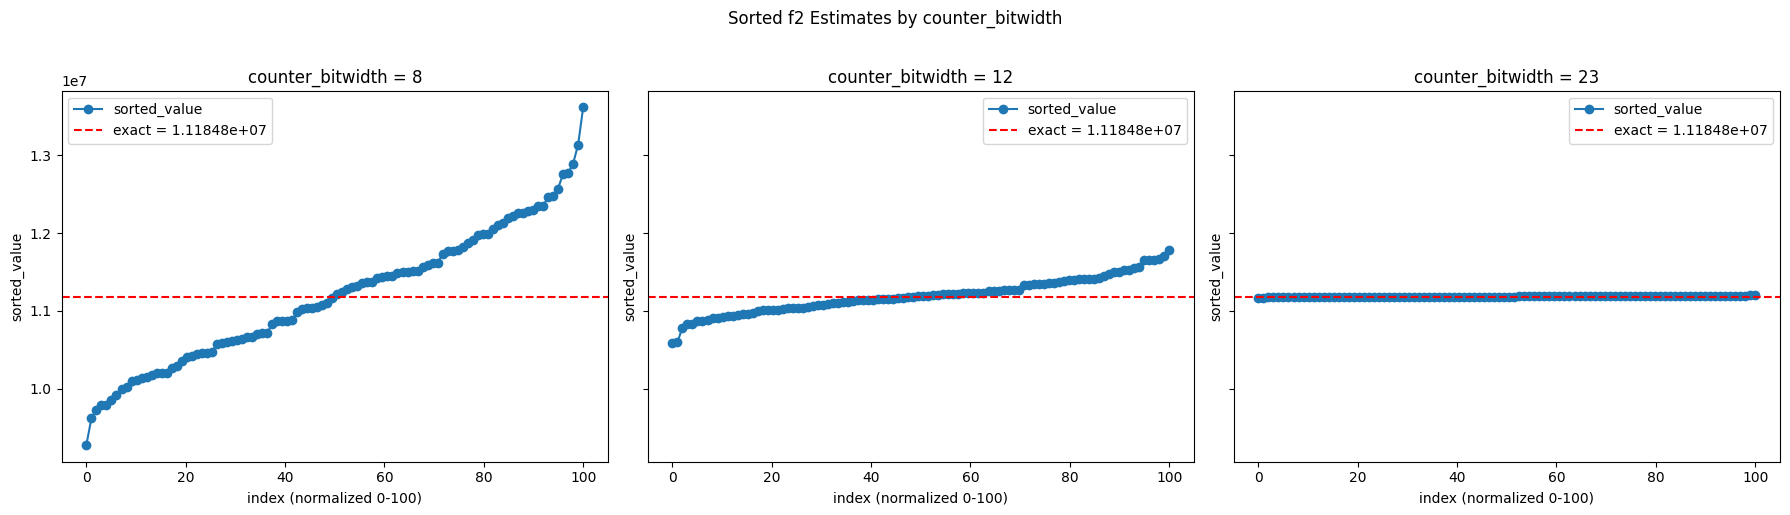

In [18]:
bitwidths = sorted(df['counter_bitwidth'].unique())
fig, axes = plt.subplots(1, len(bitwidths), figsize=(18, 5), sharey=True)

if len(bitwidths) == 1:
    axes = [axes]

for ax, width in zip(axes, bitwidths):
    group = df[df['counter_bitwidth'] == width].reset_index(drop=True)
    x_norm = np.linspace(0, 100, len(group))
    exact_value = group['exact'].iloc[0]

    ax.plot(x_norm, group['sorted_value'], marker='o', linestyle='-', label='sorted_value')
    ax.axhline(exact_value, color='r', linestyle='--', label=f'exact = {exact_value:.6g}')
    ax.set_title(f'counter_bitwidth = {width}')
    ax.set_xlabel('index (normalized 0-100)')
    ax.set_ylabel('sorted_value')
    ax.legend()

fig.suptitle('Sorted f2 Estimates by counter_bitwidth', y=1.02)
fig.tight_layout()
plt.show()

In [20]:
exact = df['exact'].iloc[0]
df_summary = df.groupby('counter_bitwidth', as_index=False).agg(
    mean_value=('raw_value', 'mean'),
    mse=('mse', 'first')
)
df_summary['num_buckets'] = 2 ** df_summary['counter_bitwidth']
df_summary['expected_variance'] = 2 * (exact**2) / df_summary['num_buckets']
df_summary['mean_error'] = (df_summary['mean_value'] - exact).abs()
df_summary['mean_error_percent'] = df_summary['mean_error'] / exact * 100
df_summary['variance_error'] = (df_summary['mse'] - df_summary['expected_variance']).abs()
df_summary['variance_error_percent'] = df_summary['variance_error'] / df_summary['expected_variance'] * 100

df_summary

,counter_bitwidth,mean_value,mse,num_buckets,expected_variance,mean_error,mean_error_percent,variance_error,variance_error_percent
0,8,11186311.84,7.730358e+11,256,9.773439e+11,1499.84,0.013410,2.043081e+11,20.904427
1,12,11197949.84,5.378333e+10,4096,6.108399e+10,13137.84,0.117461,7.300665e+09,11.951846
2,23,11184916.08,3.696151e+07,8388608,2.982617e+07,104.08,0.000931,7.135340e+06,23.923085
